# Hugo Manzano 36231

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import copy

## Pues aqui simplemente se dividió a lo que pide la actividad donde son 50000 (en train) validación (10,000) y test (10,000), y se crean los DataLoaders para procesarlo en mini batches de 128

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_train = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_data  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_data, val_data = random_split(full_train, [50000, 10000])

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=128)
test_loader  = DataLoader(test_data,  batch_size=128)

print(f'Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 337kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.16MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.07MB/s]

Train: 50000 | Val: 10000 | Test: 10000


codigo para mostrar el numero del dataset

In [3]:
def plot_number(image_tensor):
    plt.figure(figsize=(5, 5))
    plt.imshow(image_tensor.reshape(28, 28), cmap=plt.get_cmap('gray'))
    plt.axis('off')
    plt.show()

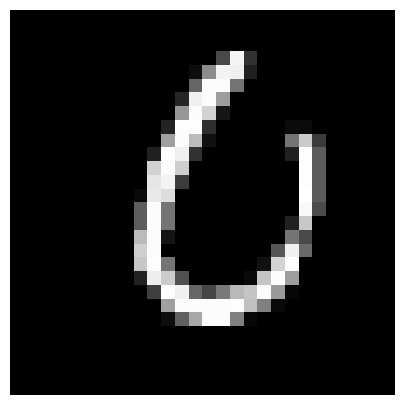

'Label: 0'

In [4]:
random_idx = torch.randint(0, len(train_data), (1,)).item()
image, label = train_data[random_idx]
plot_number(image)
display(f'Label: {label}')

Aqui construimos la red aplicando las caoas nn linear y nn relu

In [5]:
def build_model(hidden_layers):
    layers, prev = [], 784
    for h in hidden_layers:
        layers += [nn.Linear(prev, h), nn.ReLU()]
        prev = h
    layers += [nn.Linear(prev, 10)]
    return nn.Sequential(*layers)

Aqui se  implementa el loop de entrenamiento donde el train_batch actualiza los pesos una vez por mini batch usando backpropagation luego el evaluate calcula la pérdida y accuracy sin modificar los pesos, y train los une iterando por épocas y evaluando en validación al final de cada una

In [6]:
def train_batch(model, X, y, optimizer, loss_fn):
    loss = loss_fn(model(X.view(X.size(0), -1)), y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()

def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            preds = model(X.view(X.size(0), -1))
            total_loss += loss_fn(preds, y).item() * len(y)
            correct    += (preds.argmax(1) == y).sum().item()
            total      += len(y)
    return total_loss / total, correct / total

def train(model, optimizer, loss_fn, train_loader, val_loader, epochs, es=None):
    train_losses, val_losses = [], []
    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = sum(train_batch(model, X, y, optimizer, loss_fn) * len(y)
                         for X, y in train_loader)
        val_loss, val_acc = evaluate(model, val_loader, loss_fn)
        train_losses.append(epoch_loss / len(train_loader.dataset))
        val_losses.append(val_loss)
        print(f'Epoch {epoch:>2}/{epochs}  Train Loss: {train_losses[-1]:.4f}  Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}')
        if es and es.step(val_loss, model, epoch):
            es.restore(model); break
    return train_losses, val_losses

Aqui implemente el early stopping y pues solo guarda los mejores pesos cuando la val loss mejora, y detiene el entrenamiento si no hay mejora durante 5 épocas consecutivas

In [7]:
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience, self.counter = patience, 0
        self.best_loss, self.best_w = float('inf'), None
    def step(self, val_loss, model, epoch):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.best_w    = copy.deepcopy(model.state_dict())
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                print(f'  Early stopping at epoch {epoch}')
                return True
        return False
    def restore(self, model):
        model.load_state_dict(self.best_w)

In [8]:
def plot_curves(tl, vl, title):
    plt.figure(figsize=(8, 4))
    plt.plot(tl, label='Train Loss')
    plt.plot(vl, label='Validation Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.title(title); plt.legend(); plt.show()

In [9]:
loss_fn = nn.CrossEntropyLoss()

Aqui entrenamos la primera red con SGD durante maximo 20 epocas

Epoch  1/20  Train Loss: 1.1228  Val Loss: 0.5838  Val Acc: 0.8623
Epoch  2/20  Train Loss: 0.4885  Val Loss: 0.4262  Val Acc: 0.8846
Epoch  3/20  Train Loss: 0.3992  Val Loss: 0.3719  Val Acc: 0.8964
Epoch  4/20  Train Loss: 0.3616  Val Loss: 0.3462  Val Acc: 0.8997
Epoch  5/20  Train Loss: 0.3384  Val Loss: 0.3257  Val Acc: 0.9053
Epoch  6/20  Train Loss: 0.3216  Val Loss: 0.3166  Val Acc: 0.9078
Epoch  7/20  Train Loss: 0.3077  Val Loss: 0.3025  Val Acc: 0.9121
Epoch  8/20  Train Loss: 0.2960  Val Loss: 0.2941  Val Acc: 0.9149
Epoch  9/20  Train Loss: 0.2850  Val Loss: 0.2841  Val Acc: 0.9167
Epoch 10/20  Train Loss: 0.2750  Val Loss: 0.2735  Val Acc: 0.9212
Epoch 11/20  Train Loss: 0.2659  Val Loss: 0.2669  Val Acc: 0.9222
Epoch 12/20  Train Loss: 0.2572  Val Loss: 0.2583  Val Acc: 0.9246
Epoch 13/20  Train Loss: 0.2489  Val Loss: 0.2537  Val Acc: 0.9275
Epoch 14/20  Train Loss: 0.2413  Val Loss: 0.2446  Val Acc: 0.9295
Epoch 15/20  Train Loss: 0.2339  Val Loss: 0.2402  Val Acc: 0.

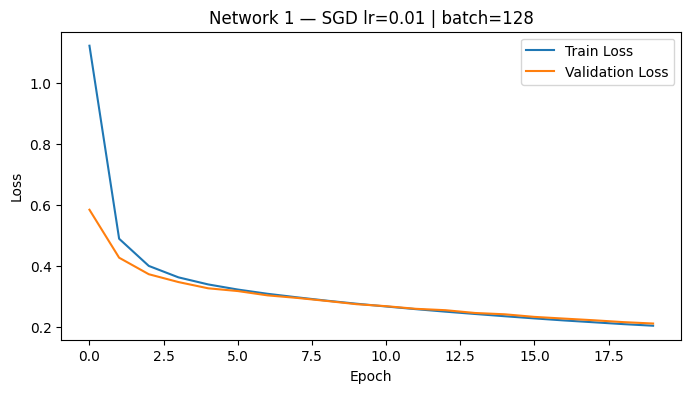

In [10]:
model_1 = build_model([200])
tl1, vl1 = train(model_1, optim.SGD(model_1.parameters(), lr=0.01), loss_fn,
                 train_loader, val_loader, epochs=20, es=EarlyStopping())
plot_curves(tl1, vl1, 'Network 1 — SGD lr=0.01 | batch=128')

Aqui pues volvemos a entrenar la red pero con ADAM en 30 epocas como maximo

Epoch  1/30  Train Loss: 0.3976  Val Loss: 0.2288  Val Acc: 0.9261
Epoch  2/30  Train Loss: 0.1752  Val Loss: 0.1752  Val Acc: 0.9457
Epoch  3/30  Train Loss: 0.1290  Val Loss: 0.1593  Val Acc: 0.9496
Epoch  4/30  Train Loss: 0.1039  Val Loss: 0.1141  Val Acc: 0.9661
Epoch  5/30  Train Loss: 0.0899  Val Loss: 0.1133  Val Acc: 0.9681
Epoch  6/30  Train Loss: 0.0802  Val Loss: 0.1099  Val Acc: 0.9688
Epoch  7/30  Train Loss: 0.0662  Val Loss: 0.1017  Val Acc: 0.9705
Epoch  8/30  Train Loss: 0.0601  Val Loss: 0.1138  Val Acc: 0.9683
Epoch  9/30  Train Loss: 0.0572  Val Loss: 0.0937  Val Acc: 0.9735
Epoch 10/30  Train Loss: 0.0486  Val Loss: 0.0815  Val Acc: 0.9778
Epoch 11/30  Train Loss: 0.0474  Val Loss: 0.0929  Val Acc: 0.9748
Epoch 12/30  Train Loss: 0.0455  Val Loss: 0.0875  Val Acc: 0.9757
Epoch 13/30  Train Loss: 0.0400  Val Loss: 0.0943  Val Acc: 0.9750
Epoch 14/30  Train Loss: 0.0366  Val Loss: 0.1120  Val Acc: 0.9732
Epoch 15/30  Train Loss: 0.0356  Val Loss: 0.1177  Val Acc: 0.

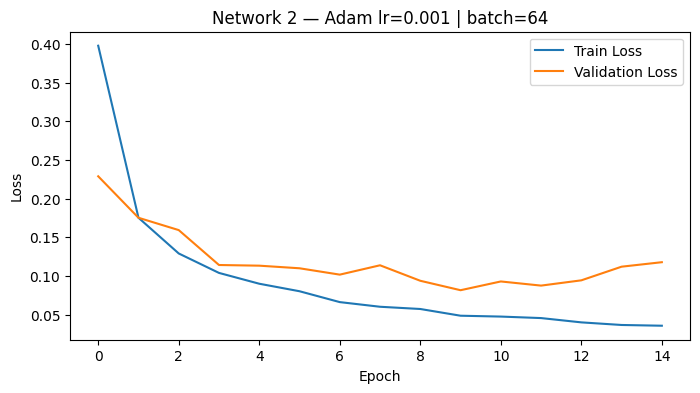

In [11]:
model_2 = build_model([256, 128, 64])
tl2, vl2 = train(model_2, optim.Adam(model_2.parameters(), lr=0.001), loss_fn,
                 DataLoader(train_data, batch_size=64, shuffle=True), val_loader,
                 epochs=30, es=EarlyStopping())
plot_curves(tl2, vl2, 'Network 2 — Adam lr=0.001 | batch=64')

Entrene esta red con ADAM durante 30 epocas y un batch size de 256

Epoch  1/30  Train Loss: 0.5128  Val Loss: 0.2898  Val Acc: 0.9133
Epoch  2/30  Train Loss: 0.2408  Val Loss: 0.1969  Val Acc: 0.9432
Epoch  3/30  Train Loss: 0.1729  Val Loss: 0.1498  Val Acc: 0.9555
Epoch  4/30  Train Loss: 0.1313  Val Loss: 0.1290  Val Acc: 0.9617
Epoch  5/30  Train Loss: 0.1079  Val Loss: 0.1188  Val Acc: 0.9653
Epoch  6/30  Train Loss: 0.0907  Val Loss: 0.1099  Val Acc: 0.9680
Epoch  7/30  Train Loss: 0.0744  Val Loss: 0.0953  Val Acc: 0.9713
Epoch  8/30  Train Loss: 0.0666  Val Loss: 0.0946  Val Acc: 0.9728
Epoch  9/30  Train Loss: 0.0564  Val Loss: 0.0913  Val Acc: 0.9727
Epoch 10/30  Train Loss: 0.0488  Val Loss: 0.0836  Val Acc: 0.9759
Epoch 11/30  Train Loss: 0.0443  Val Loss: 0.0766  Val Acc: 0.9786
Epoch 12/30  Train Loss: 0.0381  Val Loss: 0.0769  Val Acc: 0.9770
Epoch 13/30  Train Loss: 0.0312  Val Loss: 0.0765  Val Acc: 0.9786
Epoch 14/30  Train Loss: 0.0288  Val Loss: 0.0740  Val Acc: 0.9774
Epoch 15/30  Train Loss: 0.0272  Val Loss: 0.0737  Val Acc: 0.

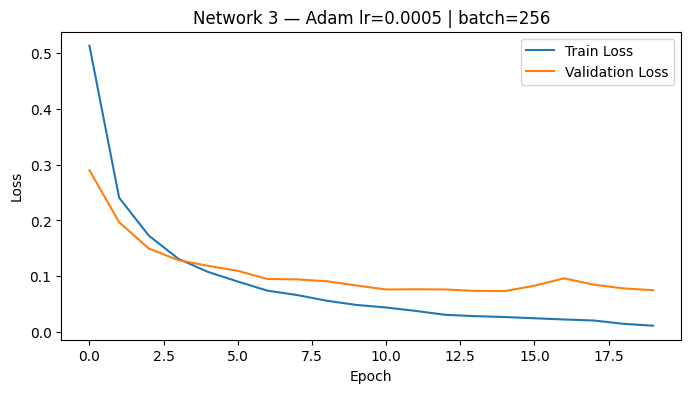

In [12]:
model_3 = build_model([512, 256])
tl3, vl3 = train(model_3, optim.Adam(model_3.parameters(), lr=0.0005), loss_fn,
                 DataLoader(train_data, batch_size=256, shuffle=True), val_loader,
                 epochs=30, es=EarlyStopping())
plot_curves(tl3, vl3, 'Network 3 — Adam lr=0.0005 | batch=256')

Aqui esta la evaluacion del modelo con las 3 redes neuronales spoiler la 3 fue la mejor (ADAM)

In [13]:
candidates = [('Network 1', model_1), ('Network 2', model_2), ('Network 3', model_3)]

print('Val accuracy:')
val_accs = {}
for name, m in candidates:
    _, acc = evaluate(m, val_loader, loss_fn)
    val_accs[name] = acc
    print(f'  {name}: {acc*100:.2f}%')

best_name  = max(val_accs, key=val_accs.get)
best_model = dict(candidates)[best_name]
print(f'\nBest model: {best_name}')

test_loss, test_acc = evaluate(best_model, test_loader, loss_fn)
print(f'Test Loss: {test_loss:.4f}  Test Accuracy: {test_acc*100:.2f}%')

Val accuracy:
  Network 1: 94.02%
  Network 2: 97.78%
  Network 3: 97.85%

Best model: Network 3
Test Loss: 0.0701  Test Accuracy: 97.84%


Conclusiones

Para empezar, no usaré jamás vscode en mi mac cuando se trate de entrenamientos y evaluaciones tarda mucho jajaj.

Ahora acerca del trabajo en si, siento que cuando se usa pytorch no hay tantos problemas por que es mas enfocado al entrenamiento o asi lo veo yo. Ademas fue interesante ver las graficas y la curva de aprendizaje donde se pudo ver cual fue la mejor (ADAM) y pues en general lo mejor fue poder comprender este tema e implementarlo ya que nunca habia tratado con redes neuronales de esta forma estuvo bien la verdad